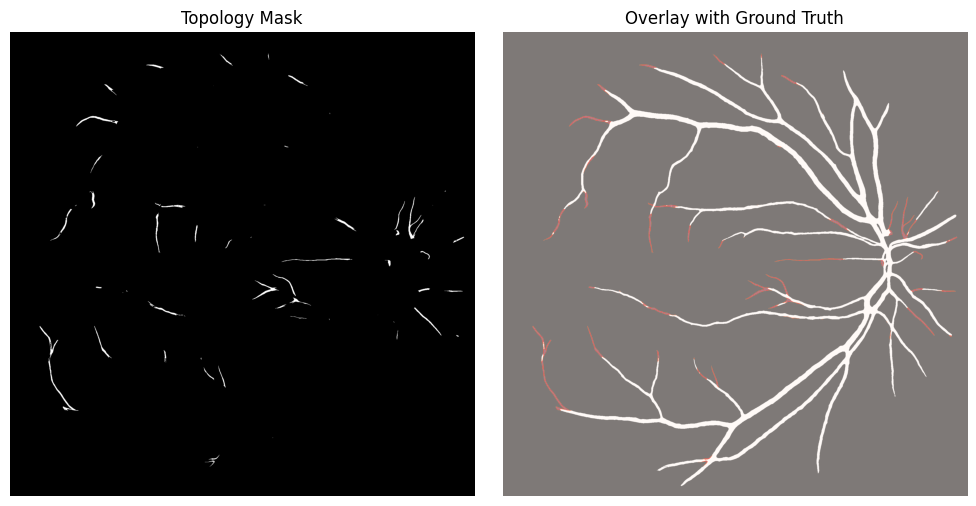

In [3]:
# 读取预测和真值图像
import cv2
import numpy as np

pred_img_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDice_0.0001_32/pred_27_A.png'
gt_img_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDice_0.0001_32/gt_27_A.png'

# 读取图像
pred_mask = cv2.imread(pred_img_path, cv2.IMREAD_GRAYSCALE)
gt_mask = cv2.imread(gt_img_path, cv2.IMREAD_GRAYSCALE)

# 将图像二值化
pred_mask = (pred_mask > 127).astype(float) 
gt_mask = (gt_mask > 127).astype(float)

# 计算漏检区域
missed_regions = np.clip(gt_mask - pred_mask, 0, 1)

# 提取骨架
from skimage.morphology import skeletonize
skeleton = skeletonize(gt_mask)

# 提取连通分量
from scipy.ndimage import label
labels, num_labels = label(missed_regions)

# 筛选与骨架相交的连通分量
topo_mask = np.zeros_like(missed_regions, dtype=bool)
for label_id in range(1, num_labels + 1):
    component = (labels == label_id)
    if np.any(component & skeleton):
        topo_mask = topo_mask | component
        
# 可视化topo_mask
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.imshow(topo_mask, cmap='gray')
plt.title('Topology Mask')
plt.axis('off')

plt.subplot(122)
plt.imshow(gt_mask, cmap='gray')
plt.imshow(topo_mask, cmap='Reds', alpha=0.5)
plt.title('Overlay with Ground Truth')
plt.axis('off')

plt.tight_layout()
plt.show()